# Closed set experiment

In this baseline experiment, we evaluate the closed set performance of the model on all recording sessions *A1*, *A2*, *B1* and *B2*.<br>
The four evaluated training/test set combinations are:<br>
*A1* → *A2*<br>
*A2* → *A1*<br>
*B1* → *B2*<br>
*B2* → *B1*

Individuals with less than 15 approaches are excluded from the training sets and the approaches per individual in the training sets are limited to 50.

In [1]:
# point this path to the folder containing all experiment data sets
DATA_DIR = r"D:\wingprint_paper\free_flight"

## Training

In [ ]:
import glob
import numpy as np
import os
import seaborn as sns
from sklearn.metrics import pairwise_distances
import sys
import torch

sys.path.append("..")

from batset import Batset
import metrics
import arcface_model
import utils

sns.set_theme()

TRAIN_DIR = os.path.join(DATA_DIR, "finalized_datasets", "A1_balanced") # the train and test directories need to be adapted to the four different cases
TEST_DIR = os.path.join(DATA_DIR, "finalized_datasets", "A2_complete")
STATS_DIR = os.path.join("stats", "closed_set")                         # for plots and models
CHECKPOINTS_DIR = os.path.join("checkpoints", "closed_set")             # for model checkpoints

os.makedirs(STATS_DIR, exist_ok=True)
os.makedirs(CHECKPOINTS_DIR, exist_ok=True)

# ensure consistent behaviour between runs by seeding random modules and disabling non-deterministic algorithms in PyTorch and CUDA
utils.seed_everything()

num_classes = len(glob.glob(os.path.join(TRAIN_DIR, '*')))

mean, std = utils.calc_mean_std_from_paths([TRAIN_DIR], limit=None)
gallery_transform = arcface_model.compose_input_transform(mean, std, image_target_size=arcface_model.IMG_SIZE)

train_data = Batset(TRAIN_DIR, transform=gallery_transform)
trainloader = torch.utils.data.DataLoader(train_data, batch_size=arcface_model.BATCH_SIZE, shuffle=True)

device = utils.get_device()

model = arcface_model.train_model(device, num_classes, trainloader)
torch.save(model.state_dict(), os.path.join(CHECKPOINTS_DIR, "model.pth"))

calculate mean and std of ['D:\\wingprint_paper\\free_flight\\finalized_datasets\\A1_balanced']


100%|██████████| 10794/10794 [01:40<00:00, 107.48it/s]


Calculated mean: tensor([0.2952, 0.2952, 0.2952]), std: tensor([0.1608, 0.1608, 0.1608])
load dataset from D:\wingprint_paper\free_flight\finalized_datasets\A1_balanced
loaded 10794 images within 15 classes
found CUDA device NVIDIA GeForce RTX 4060 Ti
initialize model
start training for maximum 50 epochs
3 mins -> Epoch 1/50.. Train loss: 23.6392, Learning rate: [1e-05]
7 mins -> Epoch 2/50.. Train loss: 3.6860, Learning rate: [8.5e-06]
12 mins -> Epoch 3/50.. Train loss: 0.7840, Learning rate: [7.2249999999999994e-06]
16 mins -> Epoch 4/50.. Train loss: 0.3210, Learning rate: [6.141249999999999e-06]
20 mins -> Epoch 5/50.. Train loss: 0.1891, Learning rate: [5.220062499999999e-06]
25 mins -> Epoch 6/50.. Train loss: 0.1263, Learning rate: [4.4370531249999995e-06]
29 mins -> Epoch 7/50.. Train loss: 0.1035, Learning rate: [3.7714951562499997e-06]
33 mins -> Epoch 8/50.. Train loss: 0.0727, Learning rate: [3.2057708828124997e-06]
early stopping due to loss < 0.15


## Build gallery and queries

After training, we fill the gallery with the training data and generate queries from the test data. Since we know which of the approaches of the training set belong together, we insert only the class centroids in the gallery. This helps eliminate outliers and reduces computational effort due to less comparisons when evaluating the queries.

In [3]:
mean, std = utils.calc_mean_std_from_paths([TEST_DIR], limit=None)
query_transform = arcface_model.compose_input_transform(mean, std, image_target_size=arcface_model.IMG_SIZE)

gallery_embeddings, gallery_names, query_embeddings, query_names = utils.build_gallery_queries(device, model, TRAIN_DIR, TEST_DIR, gallery_transform, query_transform)

# remove queries which have no counterpart in the gallery
reduced_query_embeddings = []
reduced_query_names = []

for embedding, name in zip(query_embeddings, query_names):
    if name in gallery_names:
        reduced_query_embeddings.append(embedding)
        reduced_query_names.append(name)

calculate mean and std of ['D:\\wingprint_paper\\free_flight\\finalized_datasets\\A2_complete']


100%|██████████| 24219/24219 [07:55<00:00, 50.91it/s]


Calculated mean: tensor([0.4009, 0.4009, 0.4009]), std: tensor([0.2068, 0.2068, 0.2068])
build gallery


100%|██████████| 15/15 [07:35<00:00, 30.34s/it]


generate queries


100%|██████████| 30/30 [17:08<00:00, 34.29s/it]


## Predict classes in the test set

Since we are evaluating the closed-set performance, classes that don't have a match in the training set, are skipped.

predict queries
Accuracy: 0.9990
F1 Score: 0.9990
Mean Average Precision: 0.9995
predicted 1008.0 queries out of 1009 correctly


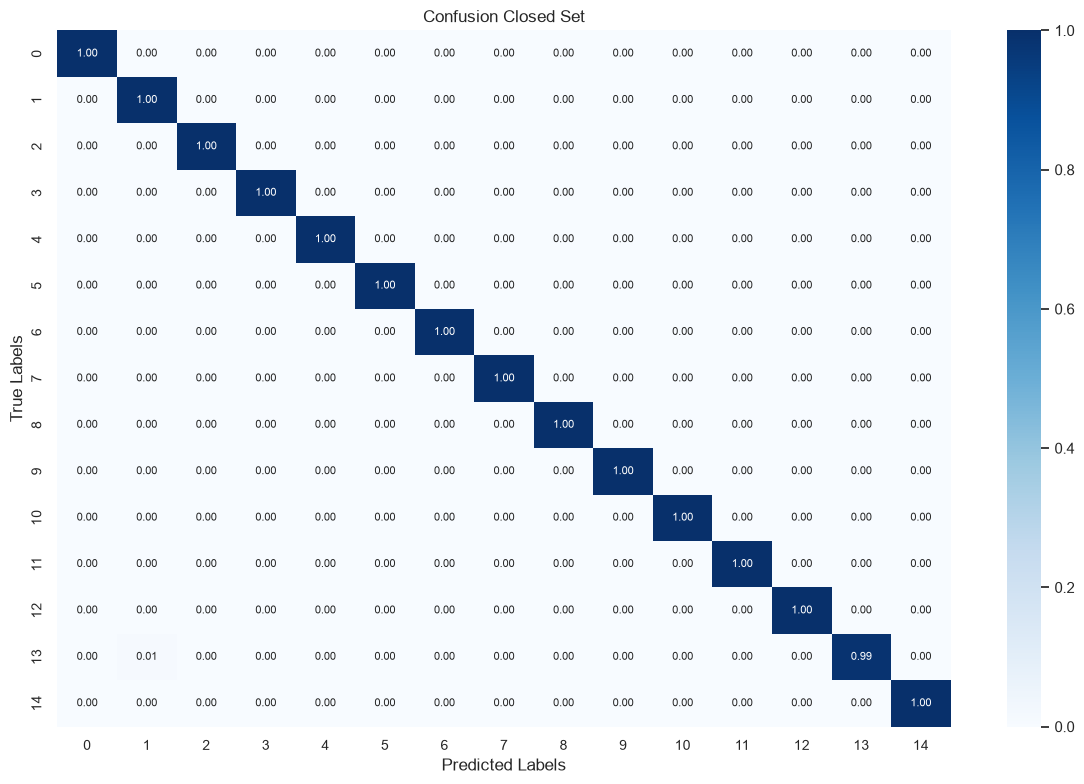

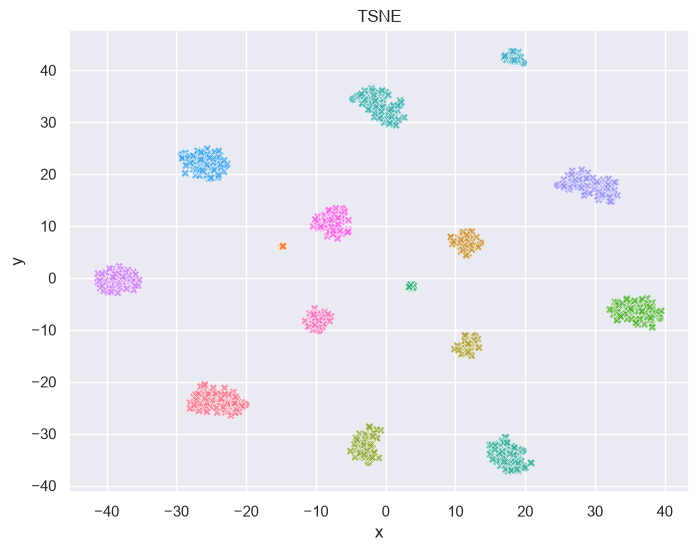

In [4]:
print("predict queries")

predictions = []
targets = []
relevances = [] # for mean average precision

for point, individual_ID in zip(reduced_query_embeddings, reduced_query_names):
    dists = pairwise_distances(point.reshape(1, -1), gallery_embeddings, metric='cosine').squeeze()

    idx = dists.argmin()
    predicted_name = gallery_names[idx]

    ranking = np.argsort(dists)
    relevance = (np.array(gallery_names)[ranking] == individual_ID).astype(int)

    predictions.append(train_data.class_map[predicted_name])
    targets.append(train_data.class_map[individual_ID])
    relevances.append(relevance)

accuracy = metrics.compute_accuracy(num_classes, predictions, targets)
f1_score = metrics.compute_f1_score(num_classes, predictions, targets)
mAP = metrics.compute_mean_average_precision(relevances)

tsne_features = gallery_embeddings+reduced_query_embeddings
tsne_labels = gallery_names+reduced_query_names
tsne_categories = ['gallery']*len(gallery_names)+['query']*len(reduced_query_names)

print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score: {accuracy:.4f}")
print(f"Mean Average Precision: {mAP:.4f}")
print(f"predicted {accuracy*len(targets)} queries out of {len(targets)} correctly")
metrics.plot_confusion(num_classes, predictions, targets, f"Confusion Closed Set", os.path.join(STATS_DIR, f"confusion_closed_set.pdf"))
metrics.plot_TSNE(num_classes, tsne_features, tsne_labels, tsne_categories, os.path.join(STATS_DIR, f"TSNE_closed_set.pdf"))